# AUPE Processing for Ries Crater Field Trip May 2025

A notebook for developing a processing library and pipeline for AUPE colour and multispectral image processing.

In this notebook we focus on calibrating to the reflectance of the calibration target.

Developed for processing of the Ries Crater field trip, May 2025.

R. Stabbins  
Natural History Museum, London, UK  
7/5/2025

# Overview


**Core Tasks**
1. Load LWAC and/or RWAC MultiSpectral Cube (MSC)
2. Correct for Exposure
3. Visualise with simple Browse Product (NIR-PAN-BLU equivalent)
4. Load corresponding RGB scene
5. Find Calibration Target in RGB scene
6. Get Patch Values from Cal Targ in MSC Frame
7. Fit Patch to Reference Values, export as Reflectance Correction Coeffients (RCC)
8. Apply RCC to exposure corrected MSC to get Reflectance MSC
9. Export MSC to ENVI, FITs, TIFF flt32 (per channel), Browse Product

**Extras**
1. Find LWAC->RWAC Rectification in sRGB images
2. Apply LWAC->RWAC Rectification to MSC, and export as 12 channel cube
3. Find matrix mapping HRC exposure corrected to RWAC exposure corrected, and then to reflectance via RWAC reflectance coefficients
4. Find RWAC->HRC rectification in sRGB images
5. Apply LRWAC full cube -> HRC rectification for mapping spectral channels to HRC.

# Log of Terminal Setup Commands

Copy each of these lines into the terminal and run one at a time.

```conda create -n aupy_dev
conda activate aupy_dev
conda install python matplotlib numpy scipy pillow pandas
conda install conda-forge::opencv

pip install click           
pip install ultralytics         
pip install --user colour-science          
pip install --user colour-checker-detection
pip install roipoly
pip install PyQt5  

```

Ensuring that the terminal is in the 'aupy' working directory, add the aupy library in development mode with:

pip install -e ./src

NOTE - replcae these instructions with a process of 1. buyild new environment from given yml file, 2. activate this environment.

Select ```aupy_dev``` as the kernel to use for running this notebook.

# Notebook and Scene Setup

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'svg' # note - requires Inkscape to be installed, and to be accessible from the terminal
# on macos, add inkscape to the path with `sudo ln -s /Applications/Inkscape.app/Contents/MacOS/inkscape /usr/local/bin/inkscape`
%matplotlib inline

In [2]:
import aupy

We're going to be looking at the AUPE scene that contains the ColorChecker in each of the WACs and HRC.

In [3]:
sol = 'SOL4' # set this manually
scene = 'sol4_1' # set this manually

# LWAC Processing

We start by processing LWAC images.

First we will process the RGB scene to reflectance units, then to sRGB colour.

Then we will load and calibrate the Geology filters to reflectance units.

We will export the sRGB colour scene, a false colour summary product of the Geology filters, and a floating point TIFF and ENVI file of the geology filter multispectral cube.

## LWAC RGB Processing

First we will load the LWAC RGB scene, and calibrate the colour of this using the calibration target in the scene.

In [4]:
lwac_rgb_loader = aupy.AupeIO('LWAC', 'RGB', sol, scene)
lwac_rgb = lwac_rgb_loader.load_frame()

In [5]:
lwac_rgb.exposure_correct()

We make a calibration target object that will allow us to interface with the expected values of the target patches, and provides tools for finding the target in the image.

In [6]:
lwac_cal_targ = aupy.CalibrationTarget()

For precision, we will manually draw around the calibration target. 

First, we drag a rectangular bounding box over the approximate area of the target. Once the area is drawn, press apce-bar to exit the process.

We then zoom into this box, so that we can precisely trace the outline of the target, by left-clicking in turn on each corner of the target. Once the outline is complete, right-click to exit the process.

Draw Bounding Box             |  Draw Outline Quadrilateral
:-------------------------:|:-------------------------:
![caltarg_bounding_box.png](./caltarg_bounding_box.png)  |  ![caltarg_outline.png](./caltarg_outline.png)

Stretching image using 99th percentile balanced
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


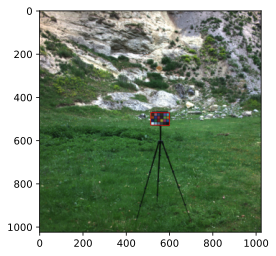

True

In [9]:
lwac_cal_targ.draw_target_outline(lwac_rgb.get_image('99b'), show=True)

Stretching image using brightest pixel unbalanced
Target Width: 85 Height: 58


/Users/sci/.local/lib/python3.13/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: Cannot compute the colour checker orientation because the reference values are not available! Please update "Colour" to a version greater-than 0.4.4.
  warn(*args, **kwargs)  # noqa: B028


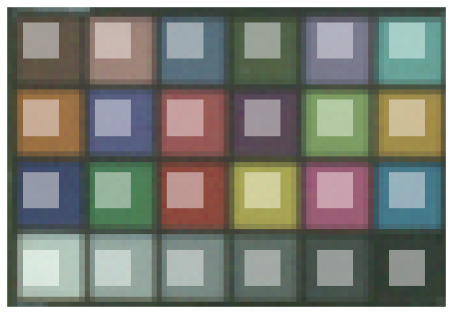

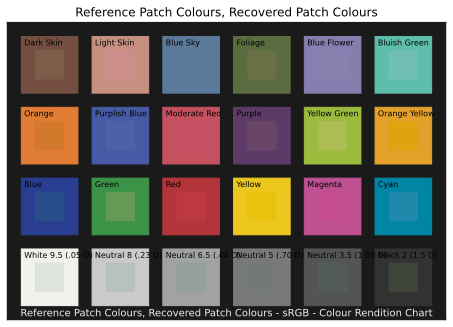

array([[ 1.92810463,  0.31883187, -0.62510269],
       [-0.19985694,  1.74110154, -0.23868452],
       [-0.03286345, -0.41136087,  1.97113782]])

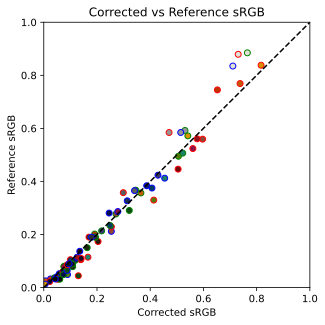

In [10]:
lwac_cal_targ.calibrate_colour(lwac_rgb, show=True)

The method produces some figures to show the success of the colour correction process.

First we see the masks used to sample the patches of the calibration target. The sample size is chosen based on the number of pixels of the target.

Then, we see a comparison between the target colour of each patch (outer box) versus the fitted colour (inner box).

In this instance, we see that mid-brightness patches are typically perceptibly close, whereas dark and bright patches have a noticeable difference.

The fit is shown quantitatively in the final plot. We can see that dark patches typically lie above the line of concordance, with brighter patches lying below.

This implies some nonlinearity in the AUPE response, that should be corrected at some stage.

We can see the results of the colour calibration by applying the colour correction matrix to our image.

Stretching image using brightest pixel unbalanced


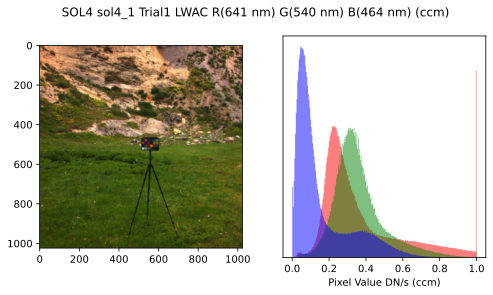

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='Pixel Value DN/s (ccm)'>], dtype=object))

In [11]:
lwac_rgb.show_image('ccm')

We can also export the colour corrected image.

In [12]:
lwac_rgb.export_image('ccm')

Exporting image using colour correction matrix
Stretching image using brightest pixel unbalanced
CCM saved to ../data/../processed/SOL4/sol4_1/Trial1/LWAC/RGB/SOL4_sol4_1_Trial1_LWAC_ccm.csv


PosixPath('../data/../processed/SOL4/sol4_1/Trial1/LWAC/RGB/SOL4_sol4_1_Trial1_LWAC_RGB_ccm.png')

We note that this colour correction isn't perfect, because it assumes that the scene illumination matches the illumination used for the Colour Checker patch expected values.

One way to correct for this would be to fit an illuminant parameterised by correlated colour temperature.

Alternatively, we can solve for the illuminant via the reflectance calibration stage.

## LWAC RGB Reflectance Calibration

Here we will load the RGB image of the LWAC as a multispectral cube, that we will calibrate the reflectance of.

We can then find the transform from the reflectance to the XYZ Colour Space, independent of illumination, from which we can convert to sRGB.

In [13]:
lwac_rgb_msc_loader = aupy.AupeIO('LWAC', 'MSC', sol, scene, filter_ids=['L1R', 'L2G', 'L3B'])
lwac_rgb_msc = lwac_rgb_msc_loader.load_frame()

In [14]:
lwac_rgb_msc.exposure_correct()

We can use the previous calibration target here.

Target Width: 85 Height: 58


/Users/sci/.local/lib/python3.13/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: Cannot compute the colour checker orientation because the reference values are not available! Please update "Colour" to a version greater-than 0.4.4.
  warn(*args, **kwargs)  # noqa: B028


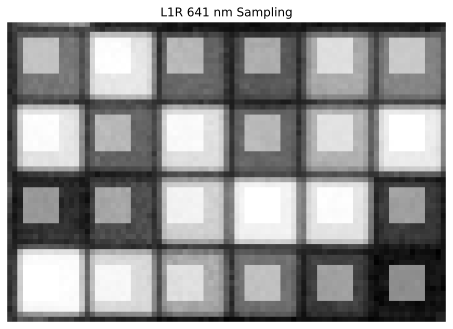

/Users/sci/.local/lib/python3.13/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: Cannot compute the colour checker orientation because the reference values are not available! Please update "Colour" to a version greater-than 0.4.4.
  warn(*args, **kwargs)  # noqa: B028


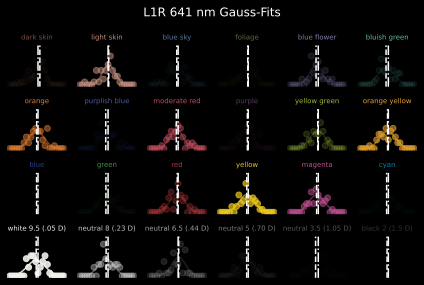

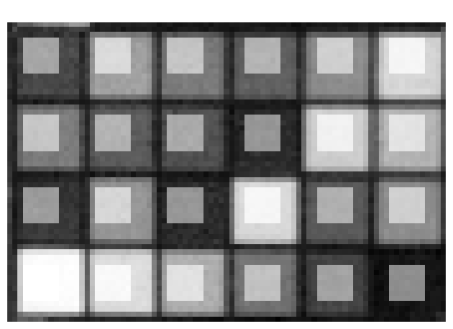

/Users/sci/.local/lib/python3.13/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: Cannot compute the colour checker orientation because the reference values are not available! Please update "Colour" to a version greater-than 0.4.4.
  warn(*args, **kwargs)  # noqa: B028


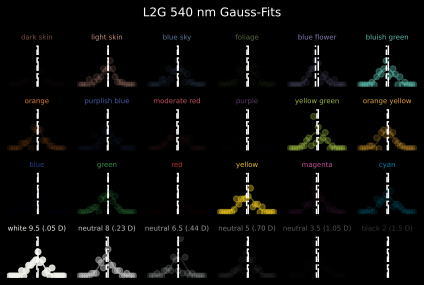

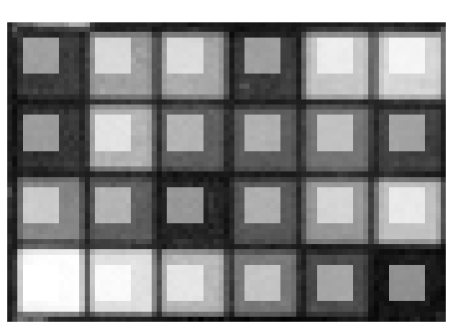

L1R 641 nm: coeff=0.000181/DN/s, offset=-0.0428
L2G 540 nm: coeff=0.0001511/DN/s, offset=-0.0573
L3B 464 nm: coeff=0.0001571/DN/s, offset=-0.0353


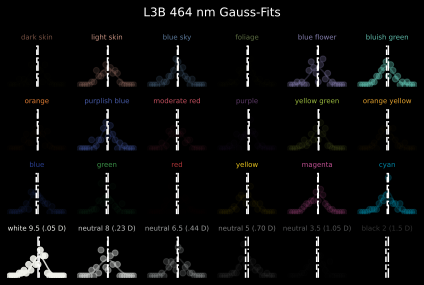

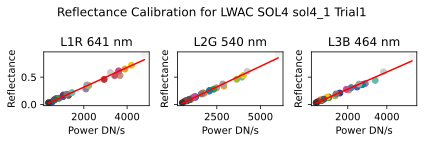

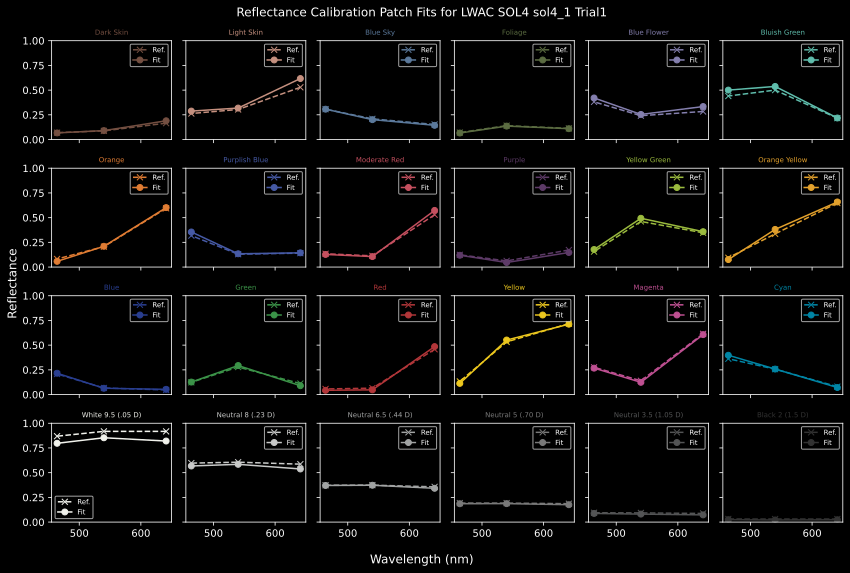

In [15]:
lwac_cal_targ.calibrate_reflectance(lwac_rgb_msc,show=True)

We can see that the generally good fits have been found for each of the Red, Green and Blue channels. The reflectance of the White patch of the target has been slightly underestimated by the fit, implying that there is either some nonlinearity for brighter values, or that the target white patch is not as bright as it once was.

We now need to perform a special colour calibration, when we produce a false colour image of the MSC, that we then convert to units of XYZ, and then apply sRGB calibration to give the true colour of the scene.

First we apply the reflectance calibration, to convert the image to reflectance units.

In [16]:
lwac_rgb_msc.apply_reflectance_calibration()

In [18]:
lwac_rgb_msc.set_false_color({'R':'L1R', 'G':'L2G', 'B':'L3B'})

Stretching image using 99th percentile unbalanced


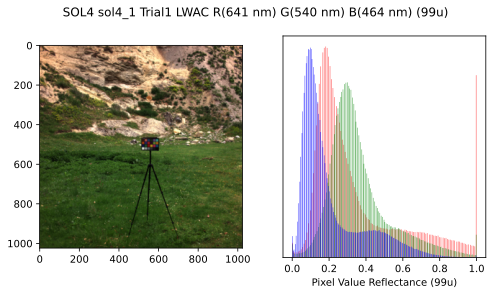

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='Pixel Value Reflectance (99u)'>], dtype=object))

In [19]:
lwac_rgb_msc.false_rgb.show_image('99u')

Target Width: 85 Height: 58


/opt/homebrew/Caskroom/miniconda/base/envs/aupy_dev/lib/python3.13/site-packages/IPython/extensions/deduperreload/deduperreload.py:290: DeprecationWarning: ast.Ellipsis is deprecated and will be removed in Python 3.14; use ast.Constant instead
  elif not isinstance(ast_elt, (ast.Ellipsis, ast.Pass)):
/opt/homebrew/Caskroom/miniconda/base/envs/aupy_dev/lib/python3.13/site-packages/IPython/extensions/deduperreload/deduperreload.py:290: DeprecationWarning: ast.Ellipsis is deprecated and will be removed in Python 3.14; use ast.Constant instead
  elif not isinstance(ast_elt, (ast.Ellipsis, ast.Pass)):
/opt/homebrew/Caskroom/miniconda/base/envs/aupy_dev/lib/python3.13/site-packages/IPython/extensions/deduperreload/deduperreload.py:290: DeprecationWarning: ast.Ellipsis is deprecated and will be removed in Python 3.14; use ast.Constant instead
  elif not isinstance(ast_elt, (ast.Ellipsis, ast.Pass)):
/opt/homebrew/Caskroom/miniconda/base/envs/aupy_dev/lib/python3.13/site-packages/IPython/exten

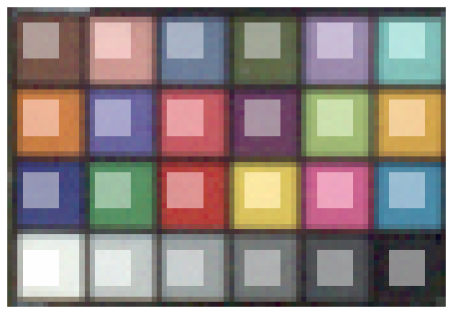

CCM Reflectance to XYZ to RGB: [[ 1.04857462  0.21378366 -0.32146992]
 [-0.04221018  1.08750987 -0.07419394]
 [ 0.01253541 -0.24486568  1.20227273]]
CCM Reflectance to RGB: [[ 1.04857462  0.21378366 -0.32146992]
 [-0.04221018  1.08750987 -0.07419394]
 [ 0.01253541 -0.24486568  1.20227273]]
Gamma Reflectance to XYZ to RGB: 1.0304354964258047
Gamma Reflectance to RGB: 1.0304354967127987


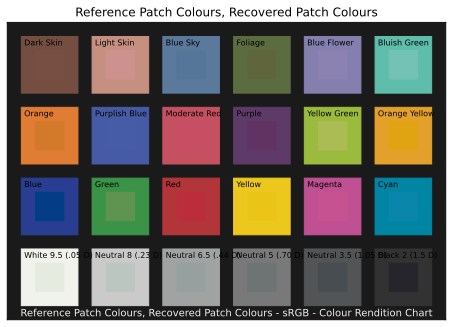

array([[ 1.04857462,  0.21378366, -0.32146992],
       [-0.04221018,  1.08750987, -0.07419394],
       [ 0.01253541, -0.24486568,  1.20227273]])

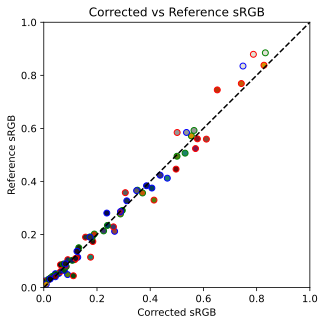

In [50]:
lwac_cal_targ.calibrate_colour(lwac_rgb_msc.false_rgb, from_reflectance=True, show=True)

We can see that this method gives slightly better performance in matching the colours, with the exception of some of the white/neutral/black patches.

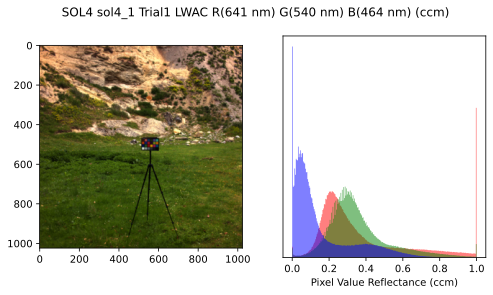

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='Pixel Value Reflectance (ccm)'>], dtype=object))

In [53]:
lwac_rgb_msc.false_rgb.show_image('ccm')

In [54]:
lwac_rgb_msc.false_rgb.export_image('ccm')

Exporting image using colour correction matrix
CCM saved to ../data/../processed/SOL4/sol4_1/Trial1/LWAC/MSC/SOL4_sol4_1_Trial1_LWAC_ccm.csv


PosixPath('../data/../processed/SOL4/sol4_1/Trial1/LWAC/MSC/SOL4_sol4_1_Trial1_LWAC_RGB_ccm.png')

Target Width: 85 Height: 58, Samples: 49


/Users/sci/.local/lib/python3.13/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: Cannot compute the colour checker orientation because the reference values are not available! Please update "Colour" to a version greater-than 0.4.4.
  warn(*args, **kwargs)  # noqa: B028


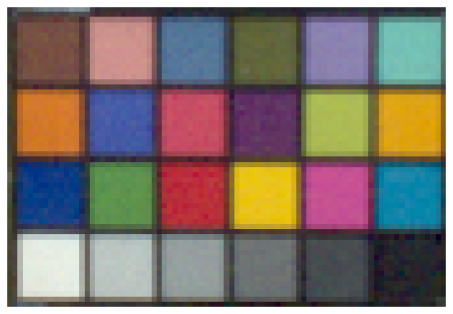

In [62]:
lwac_cal_targ.show_target(lwac_rgb_msc.false_rgb.get_image('ccm'))

Reference Colour Checker   |
:-------------------------:|
![Gretag-Macbeth_ColorChecker.jpg](./Gretag-Macbeth_ColorChecker.jpg) 

In contrast to the RGB corrected method:

Stretching image using brightest pixel unbalanced
Target Width: 85 Height: 58, Samples: 49


/Users/sci/.local/lib/python3.13/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: Cannot compute the colour checker orientation because the reference values are not available! Please update "Colour" to a version greater-than 0.4.4.
  warn(*args, **kwargs)  # noqa: B028


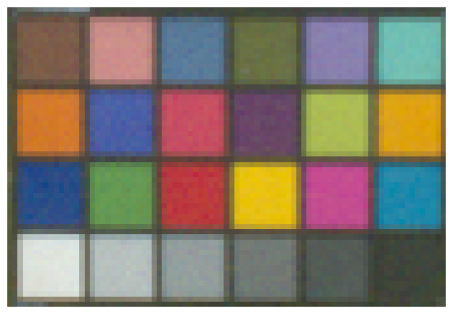

In [63]:
lwac_cal_targ.show_target(lwac_rgb.get_image('ccm'))

We consider this method to be the most accurate for colour recovery.

## Loading a WAC MSC - LWAC Narrowband filters

Prepare the frame loader, then load the frame, and get the MSC object.

In [ ]:
lwac_msc_loader = aupy.AupeIO('LWAC', 'MSC', sol, scene)
lwac_msc = lwac_msc_loader.load_frame()

Check the exposure values, and perform exposure correction.

In [ ]:
lwac_msc.exposure_correct()
lwac_msc.plot_exposures()

Set up a subset of the frame to make an RGB image.

In [ ]:
false_colour_bands = {
    'R': 'G06',
    'G': 'G03',
    'B': 'G01'
}
lwac_msc.set_false_color(false_colour_bands)

Show the false colour image.

In [ ]:
fig, ax = lwac_msc.false_rgb.show_image('99u')

Setup a calibration target, and draw the target in the false colour image.

In [ ]:
lwac_msc_cal_targ = aupy.CalibrationTarget()

In [ ]:
lwac_msc_cal_targ.draw_target_outline(lwac_msc.false_rgb.get_image('99b'))

In [ ]:
lwac_msc_cal_targ.show_target_outline(lwac_msc.false_rgb.get_image('99b'))

Perform reflectance calibration on the MSC.

In [ ]:
lwac_msc_cal_targ.calibrate_reflectance(lwac_msc, show=True)

Apply the reflectance calibration to the MSC.

In [ ]:
lwac_msc.apply_reflectance_calibration()

Show the false colour image, after reflectance calibration.

In [ ]:
lwac_msc.false_rgb.show_image('99u')

In [ ]:
lwac_msc.false_rgb.export_image('99u')

In [ ]:
lwac_msc.export_2_envi()

---

## Loading a WAC RGB as an MSC

So that we can perform reflectance calibration on the broadband channels as well.

### Loading the MSC RGB

In [ ]:
lwac_msc_rgb_loader = aupy.AupeIO('LWAC', 'MSC', sol, scene, filter_ids=['L1R', 'L2G', 'L3B'])

In [ ]:
lwac_msc_rgb = lwac_msc_rgb_loader.load_frame()

In [ ]:
lwac_msc_rgb.exposure_correct()
lwac_msc_rgb.plot_exposures()

In [ ]:
lwac_msc_rgb.set_false_color({'R': 'L1R', 'G': 'L2G', 'B': 'L3B'})

In [ ]:
lwac_msc_rgb.false_rgb.show_image('99b')

In [ ]:
lwac_msc_cal_targ.calibrate_reflectance(lwac_msc_rgb, show=True)

In [ ]:
lwac_msc_rgb.apply_reflectance_calibration()

In [ ]:
lwac_msc_rgb.false_rgb.show_image('99u')

Find the colour calibration matrix, that maps from reflectance to XYZ. Then apply the XYZ->sRGB calibration routine, as defined by the Colour Science library.

In [ ]:
lwac_msc_cal_targ.extract_ccm(lwac_msc_rgb.false_rgb)

In [ ]:
lwac_msc_rgb.false_rgb.show_image('ccm')

In [ ]:
lwac_msc_rgb.false_rgb.export_image('99u')

In [ ]:
lwac_msc_rgb.export_2_envi()

# RWAC Processing

We've now found the true labels for the LWAC, now we need to do the same analysis on the RWAC.

In [ ]:
rwac_msc_loader = aupy.AupeIO('RWAC', 'MSC', sol, scene)
rwac_msc = rwac_msc_loader.load_frame()
rwac_msc.exposure_correct()
rwac_msc.plot_exposures()

We'll also load the RGB frame for the RWAC in an MSC

In [ ]:
rwac_msc_rgb_loader = aupy.AupeIO('RWAC', 'MSC', sol, scene, filter_ids=['R1R', 'R2G', 'R3B'])
rwac_msc_rgb = rwac_msc_rgb_loader.load_frame()
rwac_msc_rgb.exposure_correct()
rwac_msc_rgb.plot_exposures()

In [ ]:
rwac_msc_rgb.set_false_color({'R': 'R1R', 'G': 'R2G', 'B': 'R3B'})

In [ ]:
rwac_msc_rgb.false_rgb.show_image('99u')

In [ ]:
rwac_msc_cal_targ = aupy.CalibrationTarget()

In [ ]:
rwac_msc_cal_targ.draw_target_outline(rwac_msc_rgb.false_rgb.get_image('99u'))

In [ ]:
rwac_msc_cal_targ.show_target_outline(rwac_msc_rgb.false_rgb.get_image('99u'))

In [ ]:
rwac_msc_cal_targ.calibrate_reflectance(rwac_msc_rgb, show=True)

In [ ]:
rwac_msc_rgb.apply_reflectance_calibration()

In [ ]:
rwac_msc_rgb.false_rgb.show_image('99u')

In [ ]:
rwac_msc_rgb.false_rgb.export_image('99u')

In [ ]:
rwac_msc_rgb.export_2_envi()

Now we apply the reflectance calibration to the MSC.

In [ ]:
rwac_msc_cal_targ.calibrate_reflectance(rwac_msc, show=True)

In [ ]:
rwac_msc.apply_reflectance_calibration()

We can see here that some of the patches for the RWAC IR channels have bad reference values, that don't fall on the line of concordance.

We need to re-take this reference data, but we can in the meantime explore the possibility of excluding these patches from the fit - TODO.

In [ ]:
rwac_msc.export_2_envi()

We've now successfully reflectance calibrated both the rwac and lwac, and the narrowband and broadband channels.

---

# LWAC -> RWAC Rectification

Now that we have the LWAC and RWAC images processed in RGB and as MSCs (Multispectral Cubes), we can find the mapping from the LWAC RGB frame to the RWAC RGB frame, and then apply this to the LWAC MSC, to give a complete RWAC 12 channel MSC.

In [ ]:
st = aupy.StereoTools(lwac_msc_rgb.false_rgb, rwac_msc_rgb.false_rgb)

Select a region in each image to find the warping for.

In [ ]:
st.select_match_regions()

In [ ]:
st.findWarp(show=True)

We're going to prepare an all-filter MSC as the destination.

In [ ]:
lrwac_msc_loader = aupy.AupeIO('LRWAC', 'MSC', sol, scene)
lrwac_msc = lrwac_msc_loader.load_frame()

In [ ]:
lrwac_msc = st.applyWarp(lwac_msc, rwac_msc, lrwac_msc)

In [ ]:
lrwac_msc.set_false_color({'R': 'G11', 'G': 'G05', 'B': 'G01'})

In [ ]:
lrwac_msc.false_rgb.show_image('99b')

In [ ]:
lrwac_msc.false_rgb.export_image('99b')

In [ ]:
lrwac_msc.plot_filter_responses()

In [ ]:
lrwac_msc.export_2_envi()

In [ ]:
# for each image, get the image, and add it to a gif
# use PIL for the gif creation
from PIL import Image
from PIL import ImageDraw, ImageFont
import os
import numpy as np
def create_gif_from_images(frame, gif_name):
    images = []
    for img in frame.imgs:
        print(f'Exporting image {img.filter_id} ')
        img_slice = Image.fromarray(np.uint8(img.get_image('raw')*255))
        # add text to the image
        img_slice = img_slice.convert("RGBA")
        text = f"{img.filter_id}: {img.cwl} nm"
        draw = ImageDraw.Draw(img_slice)
        font = ImageFont.load_default(size=24)
        draw.text((0, 0), text, fill=(255, 255, 255, 255), font=font)
        img_slice = img_slice.convert("RGB")
        images.append(img_slice)
    if images:        
        images[0].save(gif_name, save_all=True, append_images=images[1:], duration=500, loop=0)

# Create a GIF from the exported images


In [ ]:
create_gif_from_images(lrwac_msc, 'lrwac_msc.gif')

---

We just need to develop the method for colour balancing, and for producing an LRWAC browse product. One option might be to perform resampling of the cube to NPB to match CaSSIS.

We could also look at how to map from the LRWAC view to a HC view, to apply multispectral context to an HRC image.